<a href="https://colab.research.google.com/github/demisewt21/CodeAlpha_HeartDiseasePrediction/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd

# Load the heart disease dataset
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

print("✅ Data loaded successfully!")
print("Shape of data:", df.shape)
df.head()

✅ Data loaded successfully!
Shape of data: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Number of patients: 303

Target (0 = No Disease, 1 = Disease):
target
1    165
0    138
Name: count, dtype: int64


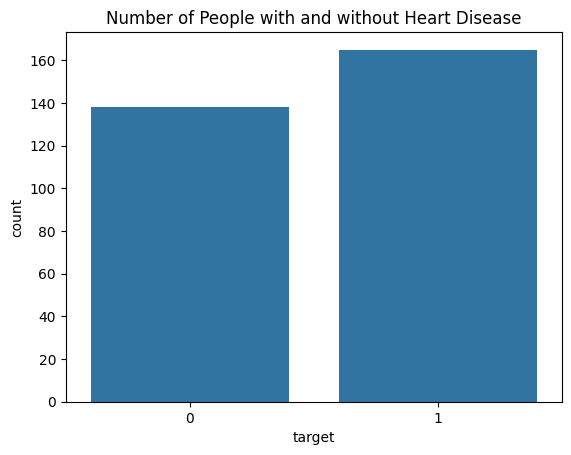

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Number of patients:", df.shape[0])
print("\nTarget (0 = No Disease, 1 = Disease):")
print(df['target'].value_counts())

# Simple plot
sns.countplot(x='target', data=df)
plt.title("Number of People with and without Heart Disease")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the numbers
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Data is ready for training!")

✅ Data is ready for training!


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else "N/A"

    print(f"\n🔥 {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC : {roc}")
    print(classification_report(y_test, y_pred))

    results[name] = acc

# Show best model
best_model = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model} with {results[best_model]:.4f} accuracy")


🔥 Logistic Regression
Accuracy: 0.8525
ROC-AUC : 0.9267241379310345
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61


🔥 Random Forest
Accuracy: 0.8361
ROC-AUC : 0.9224137931034483
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61


🔥 SVM
Accuracy: 0.8689
ROC-AUC : 0.9310344827586207
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        3

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:39:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:
# Example patient (you can change these numbers later)
sample = [[52, 1, 0, 125, 212, 0, 1, 168, 0, 1.0, 2, 2, 3]]
# Use the scaler that was already created in Cell 3
# sample_scaled = scaler.transform(sample)
import pandas as pd

sample = [[52, 1, 0, 125, 212, 0, 1, 168, 0, 1.0, 2, 2, 3]]

# Convert to DataFrame using SAME column names
sample_df = pd.DataFrame(sample, columns=X.columns)

sample_scaled = scaler.transform(sample_df)

# Use the best model that was trained in Cell 4
best_model_obj = models[best_model]

prediction = best_model_obj.predict(sample_scaled)[0]

print("Prediction for this patient:")
if prediction == 1:
    print("❤️ Has Heart Disease")
else:
    print("💚 No Heart Disease")

Prediction for this patient:
💚 No Heart Disease
